In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast


In [4]:
experiment_dir = Path("/dcs/large/u1508153/misdro/newsvendor_1d")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,algorithm,contamination,dgp,epsilon,lengthscale,num_likelihood_samples,num_observations,num_posterior_samples,num_replications,num_test_observations,posterior
uuid,,,,,,,,,,,,,,,,,,,
0fa05d3c-1054-4fbb-b934-ac54bd03e31e,0,37.632928,470.862947,22.51,0.004858,0.012731,0.000431,162.365274,bayesian_dro,0.0,truncated_normal,0.1,-1.0,100,20,100,200,50,bayes
0fa05d3c-1054-4fbb-b934-ac54bd03e31e,1,29.019986,452.303292,20.47,0.001523,0.012299,0.000238,156.239177,bayesian_dro,0.0,truncated_normal,0.1,-1.0,100,20,100,200,50,bayes
0fa05d3c-1054-4fbb-b934-ac54bd03e31e,2,28.481813,272.952600,19.77,0.001468,0.012174,0.000230,156.649642,bayesian_dro,0.0,truncated_normal,0.1,-1.0,100,20,100,200,50,bayes
0fa05d3c-1054-4fbb-b934-ac54bd03e31e,3,28.035983,357.129338,19.37,0.001535,0.012308,0.000236,150.763148,bayesian_dro,0.0,truncated_normal,0.1,-1.0,100,20,100,200,50,bayes
0fa05d3c-1054-4fbb-b934-ac54bd03e31e,4,41.149623,493.982878,28.02,0.001472,0.011825,0.000234,182.531249,bayesian_dro,0.0,truncated_normal,0.1,-1.0,100,20,100,200,50,bayes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7fd8b6a9-9b67-4aec-9419-7bfda5ca9ef8,195,77.830965,671.207351,38.22,0.001377,0.012282,0.000221,168.309604,bayesian_dro,0.0,truncated_normal,1.0,-1.0,100,20,100,200,50,bayes
7fd8b6a9-9b67-4aec-9419-7bfda5ca9ef8,196,93.030184,472.504976,41.21,0.001389,0.011919,0.000232,170.987944,bayesian_dro,0.0,truncated_normal,1.0,-1.0,100,20,100,200,50,bayes
7fd8b6a9-9b67-4aec-9419-7bfda5ca9ef8,197,71.344742,575.059916,38.04,0.001429,0.012386,0.000217,162.319181,bayesian_dro,0.0,truncated_normal,1.0,-1.0,100,20,100,200,50,bayes


In [5]:
gb = results_df.groupby(by=["algorithm", "posterior", "epsilon", "dgp"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
})
df

mean_cost              \
                                                      mean         var   
algorithm    posterior epsilon dgp                                       
bayesian_dro bayes     0.10    truncated_normal  36.294686   37.960913   
                       0.15    truncated_normal  38.787073   50.710286   
                       0.20    truncated_normal  41.385744   64.246089   
                       0.25    truncated_normal  44.030607   78.253582   
                       0.30    truncated_normal  46.697896   92.460673   
                       0.40    truncated_normal  51.974819  120.728943   
                       0.50    truncated_normal  57.064640  148.019992   
                       1.00    truncated_normal  78.225302  228.010074   
             wll       0.10    truncated_normal  36.573295   35.543690   
                       0.15    truncated_normal  39.240262   48.111015   
                       0.20    truncated_normal  41.996390   61.576472   
                       0.25    truncated_normal  44.782162   75.739769   
                       0.30    truncated_normal  47.601749   90.540531   
                       0.40    truncated_normal  53.167116  119.496863   
                       0.50    truncated_normal  58.447500  147.158840   

                                                   var_cost  
                                                       mean  
algorithm    posterior epsilon dgp                           
bayesian_dro bayes     0.10    truncated_normal  466.033242  
                       0.15    truncated_normal  449.307932  
                       0.20    truncated_normal  445.652402  
                       0.25    truncated_normal  448.571527  
                       0.30    truncated_normal  455.047287  
                       0.40    truncated_normal  471.562304  
                       0.50    truncated_normal  489.683096  
                       1.00    truncated_normal  534.243268  
             wll       0.10    truncated_normal  461.605950  
                       0.15    truncated_normal  446.523137  
                       0.20    truncated_normal  444.596491  
                       0.25    truncated_normal  449.425830  
                       0.30    truncated_normal  457.166751  
                       0.40    truncated_normal  475.042060  
                       0.50    truncated_normal  494.003370

/tmp/dcs-tmp.u1508153/ipykernel_285874/2994145069.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(bayes_bootstrap_var[i], bayes_df["mean_cost"]["mean"][i], label, ha='left', va='bottom')


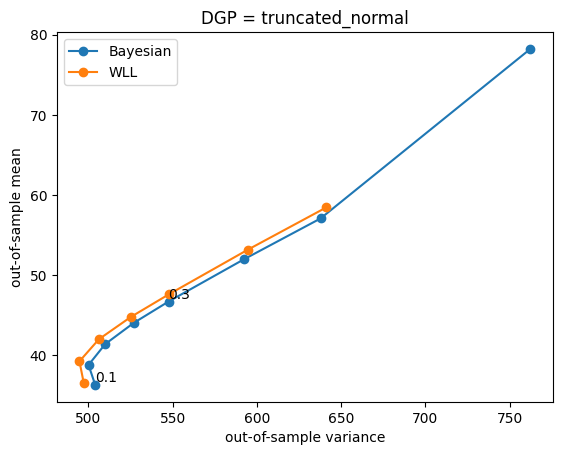

In [11]:
# dgp = "contaminated_exp"
dgp = "truncated_normal"
bayes_df = df.loc[(df.index.get_level_values("posterior") == "bayes") & (df.index.get_level_values("dgp") == dgp)]
wll_df = df.loc[(df.index.get_level_values("posterior") == "wll") & (df.index.get_level_values("dgp") == dgp)]

bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
wll_bootstrap_var = wll_df["var_cost"]["mean"] + wll_df["mean_cost"]["var"]

plt.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', label="Bayesian")
plt.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker='o', label="WLL")
# plt.plot(wll_df["new_var"], wll_df["mean_cost"], marker="x", label="WLL-NPL")
# plt.plot(mmd_df["new_var"], mmd_df["mean_cost"], marker="v", label="MMD-NPL")

plt.title(f"DGP = {dgp}")
plt.legend()
plt.xlabel("out-of-sample variance")
plt.ylabel("out-of-sample mean")
for i, label in enumerate(bayes_df.index.get_level_values("epsilon")):
    if i % 4 == 0:
        plt.text(bayes_bootstrap_var[i], bayes_df["mean_cost"]["mean"][i], label, ha='left', va='bottom')
    # if (i+2) % 4 == 0:
    #     plt.text(npl_df["new_var"][i], npl_df["mean_cost"][i], label, ha='right', va='bottom')

In [7]:
results_df.loc[results_df["dgp"] == dgp][["epsilon", "mean_cost", "new_var", "posterior"]]

KeyError: "['new_var'] not in index"